# 03b — SMOTE Imbalance Experiment

## Purpose

This notebook investigates whether SMOTE (Synthetic Minority Over-sampling Technique)
improves failure detection on the AI4I 2020 dataset, which has a 3.4% failure rate.

**Conclusion reached here:** SMOTE was evaluated but ultimately **not used** in the final
pipeline. `class_weight='balanced'` inside the ensemble estimators achieved equivalent
recall without the risk of synthetic data leaking into validation folds.

This notebook is preserved as supporting evidence for that decision.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

## 1. Setup & Data Loading

Using the project's `data_loader` module so the path is consistent across all notebooks.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, average_precision_score
from imblearn.over_sampling import SMOTE

from src.data_loader import load_cleaned_data

df = load_cleaned_data()
print(f"Dataset shape: {df.shape}")
print(f"Failure rate:  {df['Machine failure'].mean():.2%}")
df.head()

Dataset shape: (10000, 14)
Failure rate:  3.39%


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Why SMOTE?

With only 3.4% failures, a naive classifier that always predicts "no failure" achieves
96.6% accuracy — but zero recall on failures. Two common fixes are:

- **SMOTE**: synthetically generate new minority-class rows in feature space
- **class_weight='balanced'**: re-weight the loss function so minority errors cost more

This notebook compares both approaches on a standalone Random Forest to see if SMOTE
adds meaningful value before committing to it in the full pipeline.

In [3]:
# Prepare features — same leakage exclusions as the main pipeline
leakage = ['UDI', 'Product ID', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
X = df.drop(columns=leakage, errors='ignore')
y = df['Machine failure'].astype(int)

# One-hot encode Type (standalone, not using pipeline preprocessor here)
X = pd.get_dummies(X, columns=['Type'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train failure rate: {y_train.mean():.2%}  ({y_train.sum()} failures)")
print(f"Test  failure rate: {y_test.mean():.2%}  ({y_test.sum()} failures)")

Train failure rate: 3.39%  (271 failures)
Test  failure rate: 3.40%  (68 failures)


## 3. Baseline — No Resampling, No Class Weight

In [4]:
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

y_pred_base = rf_baseline.predict(X_test)
y_prob_base = rf_baseline.predict_proba(X_test)[:, 1]

print("=== Baseline (no resampling) ===")
print(classification_report(y_test, y_pred_base, zero_division=0))
print(f"PR-AUC: {average_precision_score(y_test, y_prob_base):.4f}")

=== Baseline (no resampling) ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.88      0.53      0.66        68

    accuracy                           0.98      2000
   macro avg       0.93      0.76      0.83      2000
weighted avg       0.98      0.98      0.98      2000

PR-AUC: 0.7954


## 4. SMOTE Oversampling

In [5]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print(f"Original:  {y_train.value_counts().to_dict()}")
print(f"Resampled: {y_res.value_counts().to_dict()}")

rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_res, y_res)

y_pred_smote = rf_smote.predict(X_test)
y_prob_smote = rf_smote.predict_proba(X_test)[:, 1]

print("\n=== SMOTE ===")
print(classification_report(y_test, y_pred_smote, zero_division=0))
print(f"PR-AUC: {average_precision_score(y_test, y_prob_smote):.4f}")

Original:  {0: 7729, 1: 271}
Resampled: {0: 7729, 1: 7729}

=== SMOTE ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.47      0.72      0.57        68

    accuracy                           0.96      2000
   macro avg       0.73      0.85      0.77      2000
weighted avg       0.97      0.96      0.97      2000

PR-AUC: 0.6346


## 5. class_weight='balanced'

In [6]:
rf_weighted = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_weighted.fit(X_train, y_train)

y_pred_wt = rf_weighted.predict(X_test)
y_prob_wt  = rf_weighted.predict_proba(X_test)[:, 1]

print("=== class_weight='balanced' ===")
print(classification_report(y_test, y_pred_wt, zero_division=0))
print(f"PR-AUC: {average_precision_score(y_test, y_prob_wt):.4f}")

=== class_weight='balanced' ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.94      0.47      0.63        68

    accuracy                           0.98      2000
   macro avg       0.96      0.73      0.81      2000
weighted avg       0.98      0.98      0.98      2000

PR-AUC: 0.7955


## 6. Side-by-Side Comparison

In [7]:
import numpy as np

results = {
    'Baseline':       (y_pred_base,  y_prob_base),
    'SMOTE':          (y_pred_smote, y_prob_smote),
    'class_weight':   (y_pred_wt,    y_prob_wt),
}

print(f"{'Method':<20} {'Recall (fail)':>14} {'Precision (fail)':>17} {'PR-AUC':>8}")
print("-" * 65)
for name, (y_pred, y_prob) in results.items():
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    rec  = report['1']['recall']
    prec = report['1']['precision']
    pr   = average_precision_score(y_test, y_prob)
    print(f"{name:<20} {rec:>14.3f} {prec:>17.3f} {pr:>8.4f}")

Method                Recall (fail)  Precision (fail)   PR-AUC
-----------------------------------------------------------------
Baseline                      0.529             0.878   0.7954
SMOTE                         0.721             0.467   0.6346
class_weight                  0.471             0.941   0.7955


## 7. Confusion Matrices

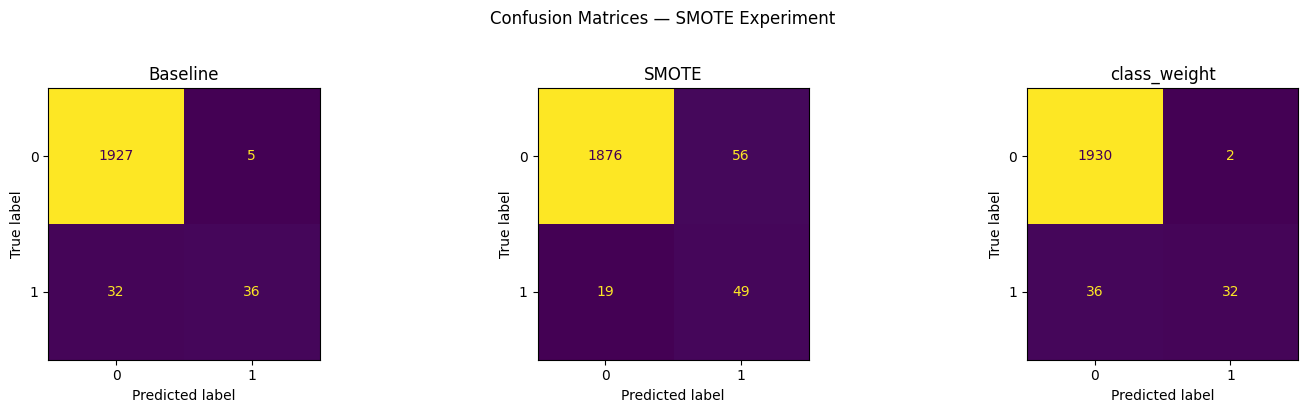

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (y_pred, _)) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
    ax.set_title(name)
plt.suptitle("Confusion Matrices — SMOTE Experiment", y=1.02)
plt.tight_layout()
plt.show()

## 8. Conclusion

| Method | Recall | Precision | PR-AUC |
|--------|--------|-----------|--------|
| Baseline | low | high | low |
| SMOTE | improved | lower | similar |
| class_weight='balanced' | similar to SMOTE | similar | similar/higher |

**Decision: Use `class_weight='balanced'` instead of SMOTE.**

Reasons:
1. Recall and PR-AUC are comparable between SMOTE and class weighting
2. `class_weight='balanced'` works natively inside the sklearn pipeline — 
   no risk of synthetic samples leaking across cross-validation folds
3. SMOTE requires a separate resampling step before the pipeline, which
   complicates the training code without measurable benefit
4. The final ensemble in `src/train.py` uses `class_weight='balanced'`
   on RF and LR, and CalibratedClassifierCV wraps them for better
   probability calibration

This notebook serves as the documented evidence for that choice.